In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

from torchvision.io.image import read_image
from torchvision.utils import draw_bounding_boxes
from torchvision.transforms.functional import to_pil_image
from torchvision.models.detection import retinanet_resnet50_fpn_v2, RetinaNet_ResNet50_FPN_V2_Weights
from torchvision import tv_tensors

import matplotlib.pyplot as plt

In [2]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [3]:
CLASSES = ['L1/L2', 'L2/L3', 'L3/L4', 'L4/L5', 'L5/S1']
BATCH_SIZE = 16
IMG_SIZE = 420
NUM_EPOCHS = 10
DATA_PATH="D:/ML/RSNA2024"

## Data Loading

In [4]:
import json

with open(os.path.join(DATA_PATH, "project-1-at-2024-08-29-11-46-bfb9d6bc.json"), "r") as f:
    annot=json.load(f)

In [5]:
annot[250]

{'id': 944,
 'annotations': [{'id': 251,
   'completed_by': 1,
   'result': [{'original_width': 420,
     'original_height': 420,
     'image_rotation': 0,
     'value': {'x': 44.47403462050599,
      'y': 76.2982689747004,
      'width': 12.11717709720373,
      'height': 10.519307589880157,
      'rotation': 0,
      'rectanglelabels': ['L5/S1']},
     'id': 'OOw_ViQJBQ',
     'from_name': 'label',
     'to_name': 'image',
     'type': 'rectanglelabels',
     'origin': 'manual'},
    {'original_width': 420,
     'original_height': 420,
     'image_rotation': 0,
     'value': {'x': 39.54727030625832,
      'y': 67.50998668442078,
      'width': 13.315579227696404,
      'height': 6.924101198402127,
      'rotation': 0,
      'rectanglelabels': ['L4/L5']},
     'id': 'CH9dF8UkfX',
     'from_name': 'label',
     'to_name': 'image',
     'type': 'rectanglelabels',
     'origin': 'manual'},
    {'original_width': 420,
     'original_height': 420,
     'image_rotation': 0,
     'value': {

In [6]:
#Boxes = [xmin, ymin, xmax, ymax]

files=[]
targets=[]


for i, a in enumerate(annot):
    fileName = a["data"]["image"].split("?d=")[1]
    fileNameParts = fileName.split("%5C")
    absolutePath = os.path.join(DATA_PATH, fileNameParts[1], fileNameParts[2], fileNameParts[3])
    annotResults = a["annotations"]
    boxesAll=[]
    labelsAll=[]
    for annotRes in annotResults:
        boxes = [[el["value"]["x"], el["value"]["y"], el["value"]["x"]+el["value"]["width"], el["value"]["y"]+el["value"]["height"]] for el in annotRes["result"]]
        # boxes = [[el["value"]["x"]/el["original_width"], el["value"]["y"]/el["original_height"], (el["value"]["x"]+el["value"]["width"])/el["original_width"], (el["value"]["y"]+el["value"]["height"])/el["original_height"]] for el in annotRes["result"]]
        labels = [el["value"]["rectanglelabels"][0] for el in annotRes["result"]]
        boxesAll = [*boxesAll, *boxes]
        labelsAll = [*labelsAll, *labels]
    files.append(absolutePath)
    targets.append({"boxes": boxesAll, "labels": labelsAll})

In [7]:
targets[250]

{'boxes': [[44.47403462050599,
   76.2982689747004,
   56.59121171770972,
   86.81757656458056],
  [39.54727030625832, 67.50998668442078, 52.86284953395472, 74.43408788282291],
  [38.61517976031957, 56.3249001331558, 52.330226364846865, 62.71637816245007],
  [42.60985352862849,
   43.54194407456725,
   54.860186418109194,
   50.59920106524633],
  [46.60452729693741,
   31.69107856191744,
   58.588548601864176,
   39.41411451398136]],
 'labels': ['L5/S1', 'L4/L5', 'L3/L4', 'L2/L3', 'L1/L2']}

In [8]:
keys = CLASSES
values = np.arange(0,len(CLASSES))
classMapping = dict(zip(keys, values))
classMapping

{'L1/L2': 0, 'L2/L3': 1, 'L3/L4': 2, 'L4/L5': 3, 'L5/S1': 4}

In [9]:
class ObjDetDataset(torch.utils.data.Dataset):
    def __init__(self, data):
        self.data = data
        self.augment=False

    def __getitem__(self, idx):
        # load images and masks
        img_path =  self.data[idx][0]
        img = read_image(img_path)
        img = img.float() / 255.0

        # get bounding box coordinates for each mask
        boxes = self.data[idx][1]["boxes"]

        labels = self.data[idx][1]["labels"]

        if len(boxes)==0:
            boxes = torch.zeros((0, 4), dtype=torch.float32).to(device)
            labels = torch.zeros((0,), dtype=torch.int64).to(device)

        image_id = idx

        # Wrap sample and targets into torchvision tv_tensors:
        img = tv_tensors.Image(img)

        mappedLabels = [classMapping[el] for el in labels]

        target = {}
        target["boxes"] = tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=img.shape)
        target["labels"] = torch.tensor(mappedLabels).type(torch.long)
        target["image_id"] = image_id

        if self.augment:
            img, target = self.transforms(img, target)

        return img, target

    def __len__(self):
        return len(self.data)

In [10]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    return tuple(zip(*batch))

import random
random.seed(474932)

trainValSplit=0.7

shuffledData = list(zip(files,targets))
random.shuffle(shuffledData)
valSplit = int(len(shuffledData)*trainValSplit)

print(f"# Training samples: {valSplit}/{len(shuffledData)}")

trainData = shuffledData[0:valSplit]
valData = shuffledData[valSplit:]

trainDataset = ObjDetDataset(trainData)
valDataset = ObjDetDataset(valData)

trainDataloader = DataLoader(trainDataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
valDataloader = DataLoader(valDataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

# Training samples: 210/300


Feature batch: torch.Size([1, 420, 420])
Labels batch: {'boxes': BoundingBoxes([], device='cuda:0', size=(0, 4), format=BoundingBoxFormat.XYXY, canvas_size=torch.Size([1, 420, 420])), 'labels': tensor([], dtype=torch.int64), 'image_id': 107}


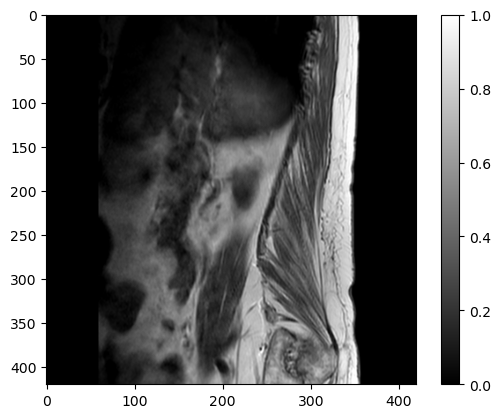

In [11]:
train_features, train_labels = next(iter(trainDataloader))
print(f"Feature batch: {train_features[0].shape}")
print(f"Labels batch: {train_labels[0]}")
img = train_features[0].squeeze()
label = train_labels[0]

fig, ax = plt.subplots()
im = ax.imshow(img, cmap='gray')
fig.colorbar(im, orientation='vertical')
plt.show()

In [12]:
import torchvision
import torch
from functools import partial
from torchvision.models.detection import RetinaNet_ResNet50_FPN_V2_Weights
from torchvision.models.detection.retinanet import RetinaNetClassificationHead

def create_model(num_classes):
    model = torchvision.models.detection.retinanet_resnet50_fpn_v2(
        weights=RetinaNet_ResNet50_FPN_V2_Weights.COCO_V1
    )
    num_anchors = model.head.classification_head.num_anchors
    model.head.classification_head = RetinaNetClassificationHead(
        in_channels=256,
        num_anchors=num_anchors,
        num_classes=num_classes,
        norm_layer=partial(torch.nn.GroupNorm, 32)
    )
    return model

model = create_model(len(CLASSES))
model.to(device)

RetinaNet(
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      

In [13]:
import math
from torchmetrics.detection import MeanAveragePrecision



num_epochs = 100
earlyStoppingPatience=5


optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)

# Decrease LR every step_size epochs by factor gamma
# lr_scheduler = torch.optim.lr_scheduler.StepLR(
#     optimizer,
#     step_size=3,
#     gamma=0.9
# )

metric=MeanAveragePrecision(box_format="xyxy").to(device)
metricVal=MeanAveragePrecision(box_format="xyxy").to(device)

scaler = torch.amp.GradScaler(enabled=True)

def train(model, optimizer, data_loader, device, epoch, print_freq, scaler=None):
    model.train()
    print( f"\nEpoch: {epoch+1}")

    lr_scheduler = None
    if epoch == 0:
        # Warm up learning rate by going from 0.001 to 1*init_LR during the first epoch
        warmup_factor = 1.0 / 1000
        warmup_iters = min(1000, len(data_loader) - 1)
        lr_scheduler = torch.optim.lr_scheduler.LinearLR(
            optimizer, start_factor=warmup_factor, total_iters=warmup_iters
        )

    for step, (images, targets) in enumerate(data_loader):
        images = list(image.to(device) for image in images)
        
        # Handle null instances (images with no objects)
        for target in targets:
            if len(target['boxes']) == 0:
                target['boxes'] = torch.zeros((0, 4), dtype=torch.float32).to(device)
                target['labels'] = torch.zeros((0,), dtype=torch.int64).to(device)

        targets = [{k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in t.items()} for t in targets]
        with torch.autocast(device_type=device, dtype=torch.float16, enabled=scaler is not None):
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        losses_reduced = sum(loss for loss in loss_dict.values())

        lossValue = losses_reduced.item()
        
        if step%print_freq ==0:
            print(f"{lossValue}")

        if not math.isfinite(lossValue):
            print(f"Loss is {lossValue}, stopping training")
            print(loss_dict)
            raise Exception()

        optimizer.zero_grad()
        if scaler is not None:
            scaler.scale(losses).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            losses.backward()
            optimizer.step()

        if lr_scheduler is not None:
            lr_scheduler.step()

@torch.no_grad()
def evaluate(model, data_loader, device):
    model.eval()

    for step, (images, targets) in enumerate(data_loader):
        images = list(image.to(device) for image in images)
        
        # Handle null instances (images with no objects)
        for target in targets:
            if len(target['boxes']) == 0:
                target['boxes'] = torch.zeros((0, 4), dtype=torch.float32).to(device)
                target['labels'] = torch.zeros((0,), dtype=torch.int64).to(device)

        targets = [{k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in t.items()} for t in targets]
        
        preds = model(images)

        metricVal.update(preds, targets)

    results = metricVal.compute()
    print(f"Validation Loss: {results}")
    return results["map"].detach().cpu().numpy()

bestMap=0
bestEpoch=0

for epoch in range(num_epochs):
    train(model, optimizer, trainDataloader, device, epoch, print_freq=2, scaler=scaler)
    # update the learning rate
    # lr_scheduler.step()
    # evaluate on the test dataset
    valMap = evaluate(model, valDataloader, device=device)
    if valMap>bestMap:
        bestMap=valMap
        bestEpoch=epoch
        print(f"New best MAP: {bestMap:.5f}")
    if epoch-bestEpoch>earlyStoppingPatience:
        print("Early Stopping")
        break
    
print("Done!")


Epoch: 1
1.4159845113754272
1.475907325744629
1.161771297454834
1.1506638526916504
0.8945871591567993
0.8148907423019409
1.1129875183105469
Validation Loss: {'map': tensor(0.), 'map_50': tensor(0.), 'map_75': tensor(0.), 'map_small': tensor(0.), 'map_medium': tensor(-1.), 'map_large': tensor(-1.), 'mar_1': tensor(0.), 'mar_10': tensor(0.), 'mar_100': tensor(0.), 'mar_small': tensor(0.), 'mar_medium': tensor(-1.), 'mar_large': tensor(-1.), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor([0, 1, 2, 3, 4], dtype=torch.int32)}

Epoch: 2
0.8222980499267578
0.855485200881958
1.2298846244812012
0.5984349250793457
0.9526944160461426
0.5016858577728271
0.9183472990989685


c:\Users\manue\anaconda3\envs\ml\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)  # noqa: B028


Validation Loss: {'map': tensor(0.0007), 'map_50': tensor(0.0033), 'map_75': tensor(9.9014e-05), 'map_small': tensor(0.0007), 'map_medium': tensor(-1.), 'map_large': tensor(-1.), 'mar_1': tensor(0.0023), 'mar_10': tensor(0.0235), 'mar_100': tensor(0.0690), 'mar_small': tensor(0.0690), 'mar_medium': tensor(-1.), 'mar_large': tensor(-1.), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor([0, 1, 2, 3, 4], dtype=torch.int32)}
New best MAP: 0.00065

Epoch: 3
0.9178507924079895
1.0164690017700195
0.7560513019561768
0.9239596128463745
1.0089519023895264
0.786390483379364
0.9818437099456787
Validation Loss: {'map': tensor(0.0004), 'map_50': tensor(0.0022), 'map_75': tensor(6.0615e-05), 'map_small': tensor(0.0004), 'map_medium': tensor(-1.), 'map_large': tensor(-1.), 'mar_1': tensor(0.0016), 'mar_10': tensor(0.0156), 'mar_100': tensor(0.0460), 'mar_small': tensor(0.0460), 'mar_medium': tensor(-1.), 'mar_large': tensor(-1.), 'map_per_class': tensor(-1.), 'mar_100_

In [ ]:
#TODO:
# Augmentation with Albumentations
# Visualisation during validation